ДЗ№1 - Михалевич Максим Алексеевич
---


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from tqdm.notebook import tqdm
from IPython.display import clear_output
import os
import random

In [2]:
data_raw = pd.read_csv('/content/cybersequrity.csv')
data = data_raw.copy()

In [15]:
data

,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,26,8,0.0,0,0,4,2,2,2,6,0.048780,0.048780,8,0.048780,0.097561,1
9996,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,5,0.000000,0.062500,1
9997,26,8,0.0,0,1,2,0,0,0,4,0.000000,0.000000,5,0.000000,0.062500,1
9998,26,8,0.0,0,0,8,6,6,7,11,0.127629,0.127629,13,0.148511,0.169392,0


In [5]:
data['Class'].value_counts()

,count
Class,
1,5096
0,4904


Заметим, что классы в целом неплохо сбалансиованы, поэтому из предобработки данных оставим только стандартизацию признаков

In [4]:
def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")

set_seed(42)

Random seed set as 42


In [6]:
X_train, X_test, y_train, y_test = train_test_split(data.drop(['Class'], axis=1),
                                                    data['Class'],
                                                    stratify=data['Class'],
                                                    test_size=0.2,
                                                    random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                    y_train,
                                                    stratify=y_train,
                                                    test_size=0.25,
                                                    random_state=42)

In [7]:
X_train.shape

(6000, 15)

Разделим данные на тренировочный, валидайионный и тестовый набор данных в соответсвии с условием задания, а дальше выполним стандартизацию StandardScaler всех созданнных наборов. После чего подготовим обертку данных для возможноти их использования в торче для обучения модели

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


In [9]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(X.values)
        self.y = torch.from_numpy(y.values).reshape(-1, 1).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return (self.X[index], self.y[index])

In [10]:
train_data = CustomDataset(X_train, y_train)
val_data = CustomDataset(X_val, y_val)
test_data = CustomDataset(X_test, y_test)

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True)

Используем вполне дефолтный размер батча, а также зададим условия обязательного перемешивания данных для стабилизации обучения

Реализуем базовый класс полносвязной нейронной сети, сразу же зададим LeakyRELU в качестве функиции активации по умолчанию, чтобы избежать проблем затухания градиентов и сильного переполнения функции активации, свойственных сигмоиде, гипербалическу тангенсу и софтмаксу

In [11]:
class BaseTorchModel(nn.Module):
  def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.LeakyReLU):
    super(BaseTorchModel, self).__init__()

    layers = [nn.Linear(input_size, hidden_size), activation()]

    for i in range(n_linear_layers - 1):
      layers.append(nn.Linear(hidden_size, hidden_size))
      layers.append(activation())

    layers.append(nn.Linear(hidden_size, num_labels))
    self.layers = nn.Sequential(*layers)

  def forward(self, x):
    y_pred = torch.sigmoid(self.layers(x))
    return y_pred

In [12]:
def train_model(model, num_epochs=100, eval_freq=10):
  train_loss_history, eval_loss_history = [], []
  train_f1_history, eval_f1_history = [], []
  global_step = 0

  model.train()
  for epoch in tqdm(range(num_epochs)):
    for batch_X, target in train_dataloader:
      optimizer.zero_grad()
      log_probs = model(batch_X.to(device))
      loss = loss_func(log_probs, target.to(device))
      loss.backward()
      optimizer.step()

      preds = (log_probs >= 0.5).int().cpu()
      f1 = f1_score(preds, target.cpu().numpy())

      train_loss_history.append((global_step, loss.item()))
      train_f1_history.append((global_step, f1))

      if global_step % eval_freq == 0:
        val_loss, val_f1 = evaluate(model)
        eval_loss_history.append((global_step, val_loss))
        eval_f1_history.append((global_step, val_f1))
        model.train()

      if global_step % 100 == 0:
        clear_output(True)

        plt.figure(figsize=(15, 5))

        plt.subplot(121)
        plt.plot(*zip(*train_loss_history), alpha=0.5, label='train_loss')
        if len(eval_loss_history):
            plt.plot(*zip(*eval_loss_history), color='red', label='eval_loss')
        plt.legend()

        plt.subplot(122)
        plt.plot(*zip(*train_f1_history), alpha=0.5, label='train_f1')
        if len(eval_f1_history):
            plt.plot(*zip(*eval_f1_history), color='red', label='eval_f1')
        plt.legend()
        plt.show()
      global_step += 1

  return model


In [13]:
@torch.no_grad()
def evaluate(model, data_loader=val_dataloader):
  model.eval()
  criterion = torch.nn.CrossEntropyLoss()
  loss_epoch = 0.
  num_epoch = 0.
  preds_list = []
  targets_list = []

  for batch_X, target in data_loader:
      log_probs = model(batch_X.to(device))
      loss = loss_func(log_probs, target.to(device))
      num = log_probs.shape[0]
      loss_epoch += loss.item() * num
      num_epoch += num

      preds_list += (log_probs >= 0.5).int().cpu().tolist()
      targets_list += target.cpu().numpy().tolist()

  f1 = f1_score(preds_list, targets_list)

  return loss_epoch / num_epoch, f1


Зададим в качестве девайса GPU если она доступна для ускорения вычислений

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Создадим первую версию сети из 3 слоев одинаковой ширины с количеством входов и выходов равному количеству используемых признаков. На выходе оставим один нейрон, так как решаемая задача является задачей бинарной классификации

In [22]:
model = BaseTorchModel(1, 15, 15, 3)
model.to(device)

BaseTorchModel(
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=15, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=15, out_features=15, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=15, out_features=1, bias=True)
  )
)

Зададим функцию потерь так, как указано в задании. В качестве оптимизатора выберем AdamW, так как он быстрее сходится по сравнению с классическим SGD и имеет ниже шанс провала в локальный минимум функции

In [23]:
loss_func = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

параметр lr пока оставим как 10^(-3) и далее попробуем выполнить его подбор. Количество эпох используем дефолтное для созданной архитектуры = 100. В процессе обучения постараемся отследить выход кривой валидации на плато, если удасться найти данную точку, то примем ее в качестве точки остановки обучения, чтобы избежать переобучения сети.

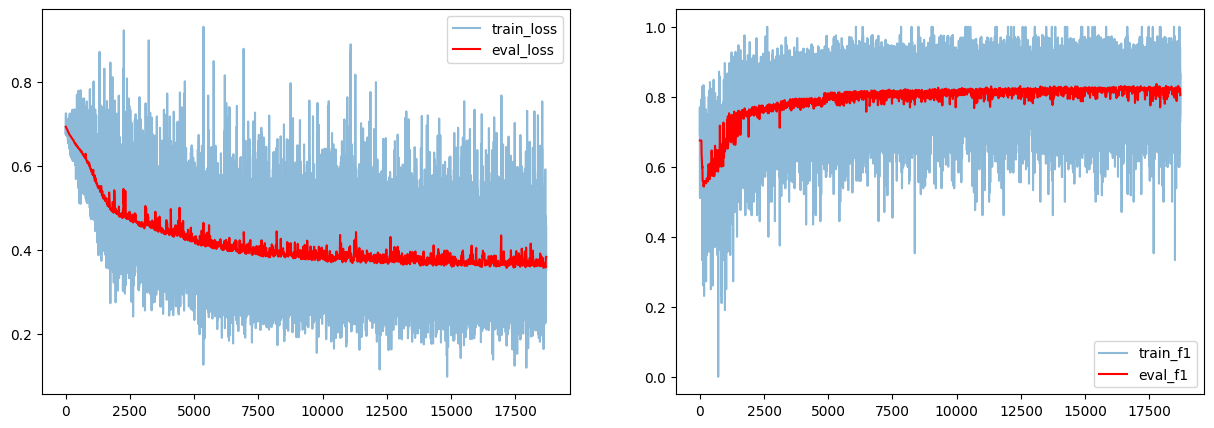

In [24]:
model = train_model(model, num_epochs=100)

Анализируя итоги обучения можно заключить, что тренд на снижение валидационного лоса определенно все еще сохранятся, однако при увеличении количества эпох, серьезно будет увеличено и время обучения. Проведем classification_report, а далее попробуем увеличить lr и выполнить обучение еще раз с тем же количеством эпох

In [27]:
result = evaluate(model, data_loader=test_dataloader)
print(f'Loss test: {result[0]}\nf1_test: {result[1]}')

Loss test: 0.37241474771499633
f1_test: 0.822401614530777


In [28]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values).float().to(device)
    pred_probs = model(X_test_tensor)
    pred_classes = (pred_probs >= 0.5).int().cpu().numpy().flatten()

print(classification_report(y_test, pred_classes))


              precision    recall  f1-score   support

           0       0.80      0.85      0.83       981
           1       0.85      0.80      0.82      1019

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.83      0.82      0.82      2000



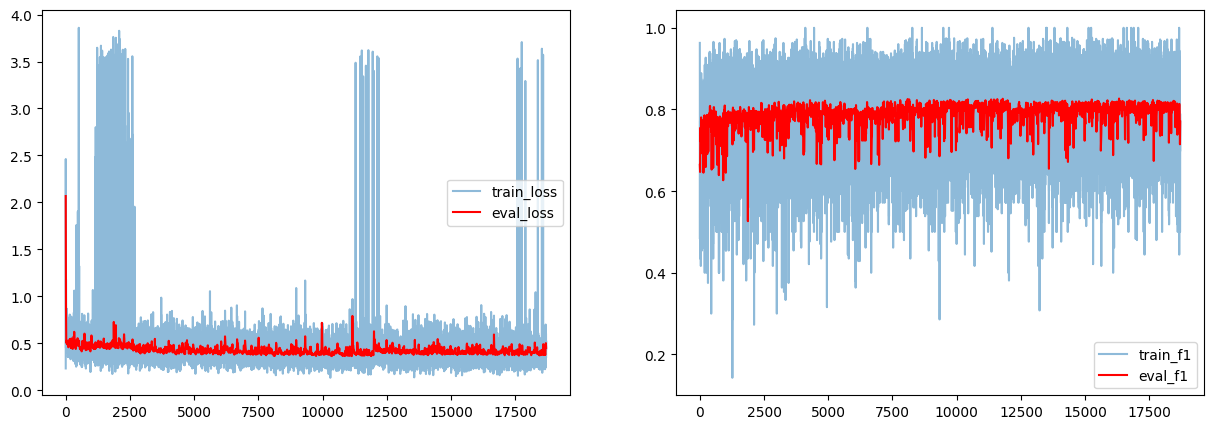

In [29]:
loss_func = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01)
model = train_model(model, num_epochs=100)

Резкое снижение лоса а затем выход на плато может свидетельствовать о слишком высоком значении lr для нашей задачи. Возможно, оптимизатор уперся в локальный минимум функции и не может из него выбраться, "прыгая" в разные стороны в его окрестности, что препядствует дальнейшей сходимости алгоритма. В данной ситуации лучше будет остаться на значении lr = 0.001

In [30]:
result = evaluate(model, data_loader=test_dataloader)
print(f'Loss test: {result[0]}\nf1_test: {result[1]}')

Loss test: 0.44090525031089783
f1_test: 0.8100250626566416


In [31]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values).float().to(device)
    pred_probs = model(X_test_tensor)
    pred_classes = (pred_probs >= 0.5).int().cpu().numpy().flatten()

print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       981
           1       0.83      0.79      0.81      1019

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



По метрикам модель с более низким lr также немного проигрывает и по 0 и по 1 классу

Добавим слои батч ннормализации и выполним обучение еще раз

In [34]:
class BeseTorchModel_BN(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.LeakyReLU):
        super(BeseTorchModel_BN, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), nn.BatchNorm1d(hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(activation())

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

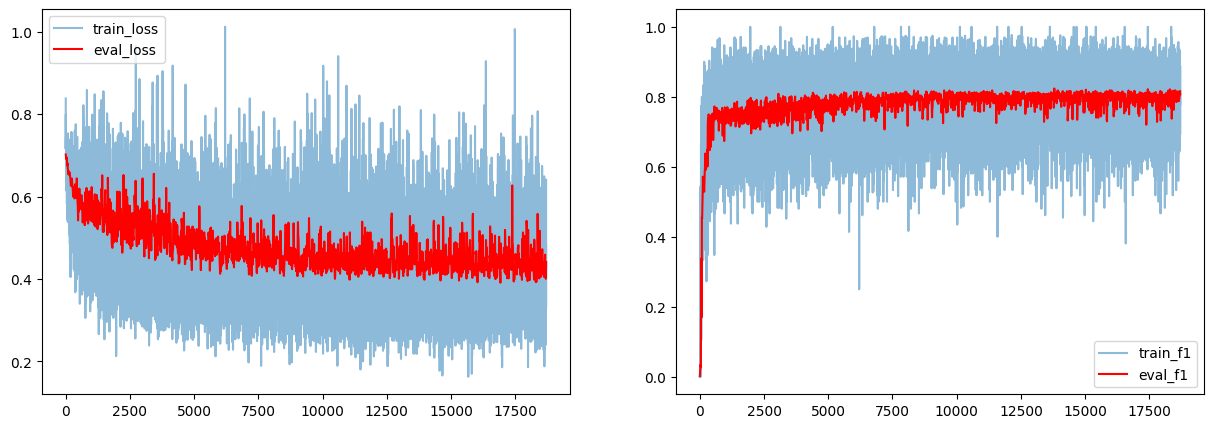

In [35]:
model_bn = BeseTorchModel_BN(1, 15, 15, 3)
model_bn.to(device)

loss_func = nn.BCELoss()
optimizer = optim.AdamW(model_bn.parameters(), lr=0.001)
model_bn = train_model(model_bn, num_epochs=100)

In [36]:
result = evaluate(model_bn, data_loader=test_dataloader)
print(f'Loss test: {result[0]}\nf1_test: {result[1]}')

Loss test: 0.4113035912513733
f1_test: 0.8089887640449438


In [37]:
from sklearn.metrics import classification_report

model_bn.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values).float().to(device)
    pred_probs = model_bn(X_test_tensor)
    pred_classes = (pred_probs >= 0.5).int().cpu().numpy().flatten()

print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       981
           1       0.81      0.81      0.81      1019

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



Прироста при использовании батч нормализации не произошло, попробуем доработать архитектуру сети, сделав ее резко расширяющейся сначала и затем сужающейся. Также добавим еще пару скрытых слоев

In [21]:
class BeseTorchModel_BN_2(nn.Module):
    def __init__(self, input_size):
        super(BeseTorchModel_BN_2, self).__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.fc4 = nn.Linear(16, 1)

        self.negative_slope = 0.01

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x, negative_slope=self.negative_slope)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x, negative_slope=self.negative_slope)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.leaky_relu(x, negative_slope=self.negative_slope)


        y_pred = torch.sigmoid(self.fc4(x))
        return y_pred


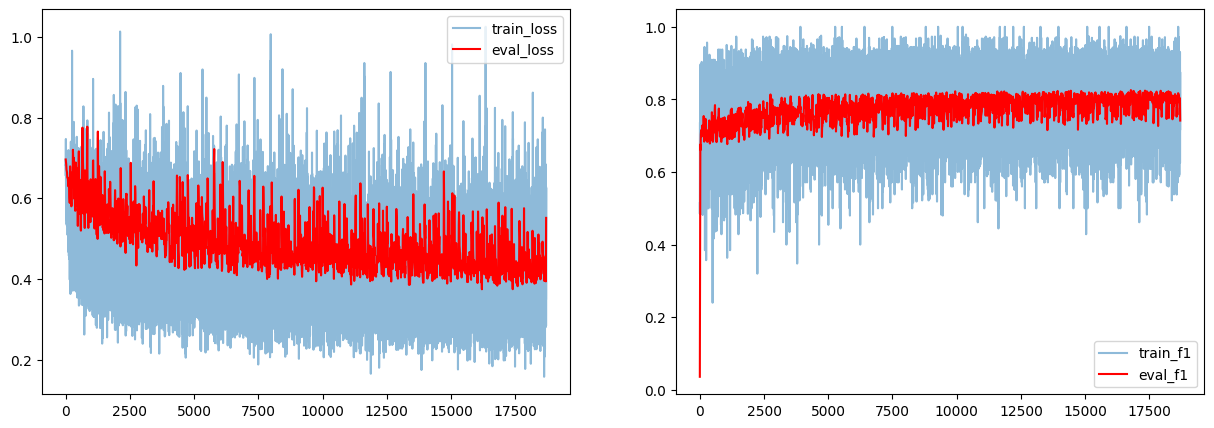

In [47]:
model_bn = BeseTorchModel_BN_2(15)
model_bn.to(device)

loss_func = nn.BCELoss()
optimizer = optim.AdamW(model_bn.parameters(), lr=0.001)
model_bn = train_model(model_bn, num_epochs=100)

In [48]:
result = evaluate(model_bn, data_loader=test_dataloader)
print(f'Loss test: {result[0]}\nf1_test: {result[1]}')

Loss test: 0.4022215187549591
f1_test: 0.8165740272865083


In [49]:
from sklearn.metrics import classification_report

model_bn.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values).float().to(device)
    pred_probs = model_bn(X_test_tensor)
    pred_classes = (pred_probs >= 0.5).int().cpu().numpy().flatten()

print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       981
           1       0.84      0.79      0.82      1019

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



В целом улучшенная ахритектура с использованием батч норма позволила вполнтую прбилизиться к метрикам бейзлайн модели. Возможно стоит попробовать чуть увеличить количество эпох обучения для дополнительной минимизации лоса и повышения метрик. Однако по графику динамики лоса, будто бы алгоритм уже сошелся к какому-то оптимуму.

Попробуем немного изменить архитектуру и воспользоваться дропаутом, однако, так как мы не наблюдаем явного переобучения в данной задаче, я бы не ожидал от введения дропаута каких-то улучшений качества модели.

In [16]:
class BeseTorchModel_BN_2_Dropout(nn.Module):
    def __init__(self, input_size, dropout_rate=0.3):
        super(BeseTorchModel_BN_2_Dropout, self).__init__()

        self.dropout_rate = dropout_rate

        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.dropout3 = nn.Dropout(dropout_rate)

        self.fc4 = nn.Linear(16, 1)

        self.negative_slope = 0.01

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x, negative_slope=self.negative_slope)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x, negative_slope=self.negative_slope)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.leaky_relu(x, negative_slope=self.negative_slope)
        x = self.dropout3(x)

        y_pred = torch.sigmoid(self.fc4(x))
        return y_pred

немного увеличим кол-во эпох обучения из-за введения дропаута

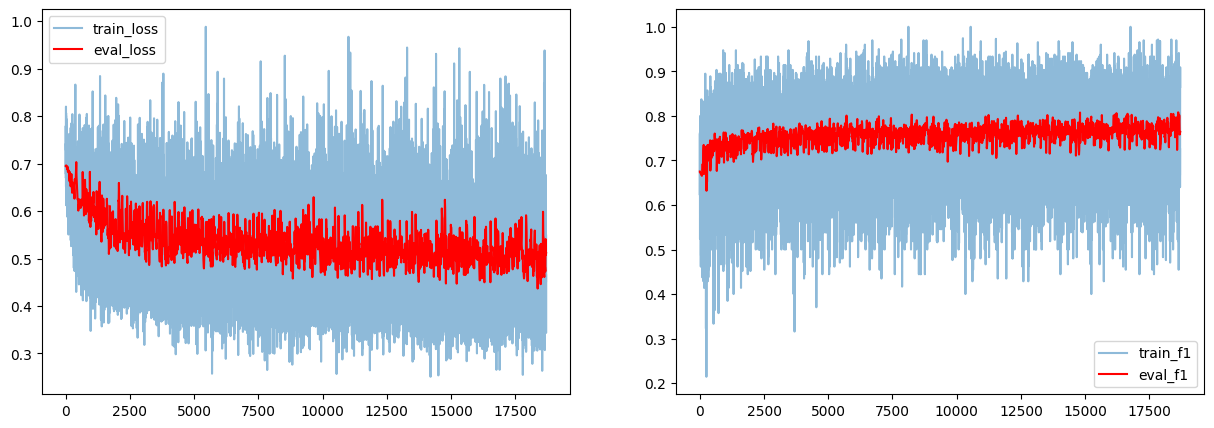

In [17]:
model_bn_dr = BeseTorchModel_BN_2_Dropout(15)
model_bn_dr.to(device)

loss_func = nn.BCELoss()
optimizer = optim.AdamW(model_bn_dr.parameters(), lr=0.001)
model_bn_dr = train_model(model_bn_dr, num_epochs=100)

In [19]:
from sklearn.metrics import classification_report

model_bn_dr.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values).float().to(device)
    pred_probs = model_bn_dr(X_test_tensor)
    pred_classes = (pred_probs >= 0.5).int().cpu().numpy().flatten()

print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.81      0.52      0.63       981
           1       0.65      0.88      0.75      1019

    accuracy                           0.70      2000
   macro avg       0.73      0.70      0.69      2000
weighted avg       0.73      0.70      0.69      2000



Как и ожидалось результат стал хуже, вижу сам лучшим решением в данном случае вернуться к либо дефолтному варианту, либо варианту с интегрироавнным батч нормом и поэксперементировать с размером самого батча

In [20]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

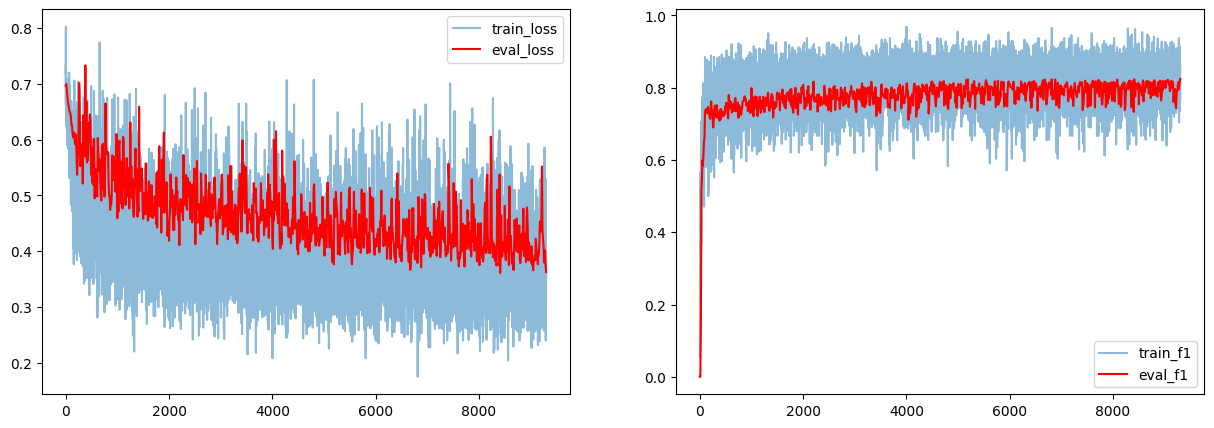

In [22]:
model_bn = BeseTorchModel_BN_2(15)
model_bn.to(device)

loss_func = nn.BCELoss()
optimizer = optim.AdamW(model_bn.parameters(), lr=0.001)
model_bn = train_model(model_bn, num_epochs=100)

In [25]:
from sklearn.metrics import classification_report

model_bn.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values).float().to(device)
    pred_probs = model_bn(X_test_tensor)
    pred_classes = (pred_probs >= 0.5).int().cpu().numpy().flatten()

print(classification_report(y_test, pred_classes))


              precision    recall  f1-score   support

           0       0.81      0.77      0.79       981
           1       0.79      0.82      0.81      1019

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



Попробуем вернуться к первому варианту архитектуры, так как обучение там было самым стабильным и шум на валидационной выборке был сильно ниже. Обучим ее с батч сайзом = 64 и увеличим количество эпох до 500

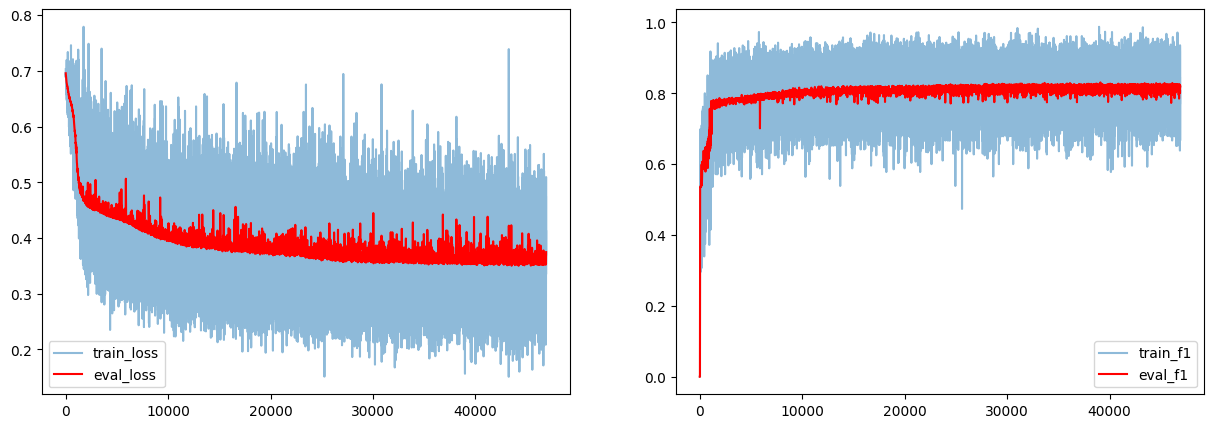

In [31]:
model = BaseTorchModel(1, 15, 15, 3)
model.to(device)
loss_func = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
model = train_model(model, num_epochs=500)

In [32]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values).float().to(device)
    pred_probs = model(X_test_tensor)
    pred_classes = (pred_probs >= 0.5).int().cpu().numpy().flatten()

print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       981
           1       0.83      0.81      0.82      1019

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



Для финального эксперемента попробуем уменьшить батч сайз и увелечитьи lr

In [34]:
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=16, shuffle=True)

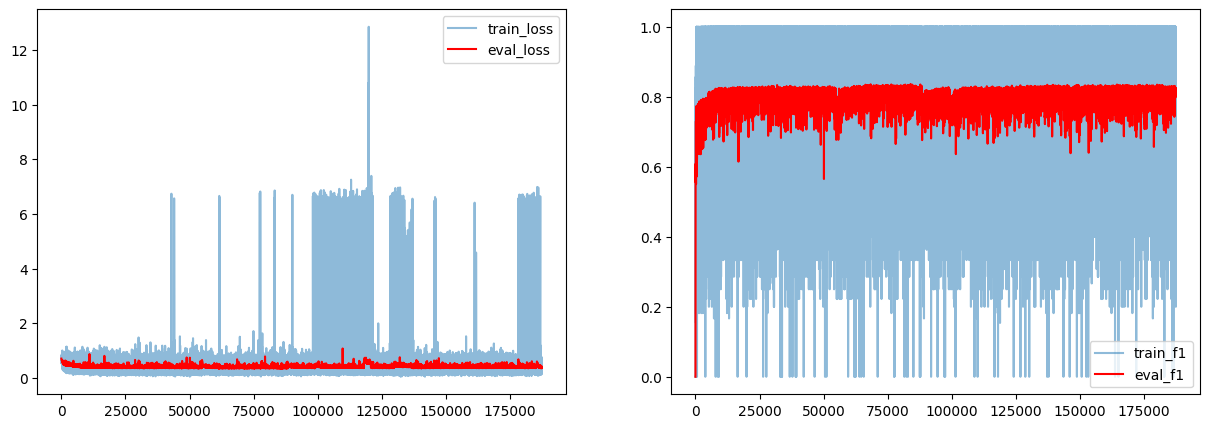

In [35]:
model = BaseTorchModel(1, 15, 15, 3)
model.to(device)
loss_func = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.005)
model = train_model(model, num_epochs=500)

In [36]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values).float().to(device)
    pred_probs = model(X_test_tensor)
    pred_classes = (pred_probs >= 0.5).int().cpu().numpy().flatten()

print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.77      0.89      0.83       981
           1       0.87      0.75      0.81      1019

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



Увеличение числа эпох приводит к смешению метрик в сторону повышения точночти определения 1 класса, однако f мера остается постоянной. Также серьезно повышается и время обучения модели. Какую конкретно модель выбрать в данном случае зависит от требуемых технических метрик в задаче